<div style='background: linear-gradient(135deg, #667eea 0%, #b1d54e 100%); padding: 40px; border-radius: 15px; box-shadow: 0 10px 30px rgba(0,0,0,0.3);'>
    <h1 style='color: white; text-align: center; font-size: 48px; margin: 0; font-weight: 800; text-shadow: 2px 2px 4px rgba(0,0,0,0.3);'>HELP ONG x VisionDataLab</h1>
    <h2 style='color: #e0e7ff; text-align: center; font-size: 28px; margin-top: 15px; font-weight: 300;'>Merge datasets</h2>
    <p style='color: white; text-align: center; font-size: 16px; margin-top: 20px; opacity: 0.9;'>TP ML 2</p>
</div>

<style>
    /* Style global */
    body {
        font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    }
    
    /* Headers stylés */
    h1, h2, h3, h4 {
        font-weight: 700;
    }
    
    /* Sections colorées */
    .section-header {
        background: linear-gradient(90deg, #f093fb 0%, #f5576c 100%);
        padding: 20px;
        border-radius: 10px;
        color: white;
        margin: 30px 0 20px 0;
        box-shadow: 0 5px 15px rgba(0,0,0,0.2);
    }
    
    .info-box {
        background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
        padding: 20px;
        border-radius: 10px;
        color: white;
        margin: 15px 0;
        box-shadow: 0 5px 15px rgba(0,0,0,0.1);
    }
    
    .warning-box {
        background: linear-gradient(135deg, #f093fb 0%, #f5576c 100%);
        padding: 20px;
        border-radius: 10px;
        color: white;
        margin: 15px 0;
        box-shadow: 0 5px 15px rgba(0,0,0,0.1);
    }
    
    .success-box {
        background: linear-gradient(135deg, #43e97b 0%, #38f9d7 100%);
        padding: 20px;
        border-radius: 10px;
        color: white;
        margin: 15px 0;
        box-shadow: 0 5px 15px rgba(0,0,0,0.1);
    }
    
    /* Badges */
    .badge {
        display: inline-block;
        padding: 8px 15px;
        border-radius: 20px;
        font-size: 14px;
        font-weight: 600;
        margin: 5px;
    }
    
    .badge-primary {
        background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
        color: white;
    }
    
    .badge-success {
        background: linear-gradient(135deg, #43e97b 0%, #38f9d7 100%);
        color: white;
    }
    
    .badge-warning {
        background: linear-gradient(135deg, #fa709a 0%, #fee140 100%);
        color: white;
    }
    
    /* Dividers */
    .divider {
        height: 3px;
        background: linear-gradient(90deg, #667eea 0%, #764ba2 100%);
        border: none;
        margin: 30px 0;
        border-radius: 5px;
    }
</style>

# Import package and config

In [168]:
import sys
from pathlib import Path

root_path = Path.cwd().parent 
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

from src.config import paths
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import pycountry


## Configs

In [169]:
raw_dir=paths.DATA_DIR/"raw"
raw_dir

WindowsPath('C:/Users/HP/Desktop/temp/TODO/SEMESTRE_2/ML2/projet/data/raw')

In [170]:
root=paths.ROOT_DIR
with open(root / "configs" / "variables.yaml", "r") as f:
    config = yaml.safe_load(f)
    
sources = config["sources"]
print("Sources configurées :", list(sources.keys()))

Sources configurées : ['sante_wdi', 'sante_who', 'social_poverty_mpi', 'social_literacy', 'social_poverty_2_15', 'social_schooling', 'social_undernourishment', 'securite_civil', 'securite_political']


# Main dataset

In [171]:
df_main=pd.read_csv(raw_dir/"Country-data.csv")
df_final = df_main.copy()
df_main.info()


<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB


In [172]:
df_main.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [173]:
len(df_main)

167

## Country Mapping 

In [174]:
def get_iso_code(country_name):
    try:
        return pycountry.countries.lookup(country_name).alpha_3
    except (LookupError, AttributeError):
        return None


df_final['iso_code'] = df_final['country'].apply(get_iso_code)

In [175]:
# Dictionnaire de correspondance entre le dataset et la norme ISO
mapping_corrections = {
    'Brunei': 'Brunei Darussalam',
    'Cape Verde': 'Cabo Verde',
    'Congo, Dem. Rep.': 'Congo, The Democratic Republic of the',
    'Congo, Rep.': 'Congo',
    "Cote d'Ivoire": "Côte d'Ivoire",
    'Macedonia, FYR': 'North Macedonia',
    'Micronesia, Fed. Sts.': 'Micronesia, Federated States of',
    'Russia': 'Russian Federation',
    'St. Vincent and the Grenadines': 'Saint Vincent and the Grenadines',
    'Turkey': 'Türkiye'
}

# Application des corrections sur la colonne 'country'
df_final['country'] = df_final['country'].replace(mapping_corrections)

# Ré-exécution du mapping ISO
df_final['iso_code'] = df_final['country'].apply(get_iso_code)

In [176]:
# Vérification des valeurs manquantes après correction
missing_after = df_final[df_final['iso_code'].isna()]

if missing_after.empty:
    print("Succès total : Tous les pays ont désormais un code ISO Alpha-3.")
else:
    print(f"Il reste encore des anomalies pour : {missing_after['country'].unique()}")

# Validation de la cohérence dimensionnelle
n_lignes = len(df_final)
n_uniques = df_final['iso_code'].nunique()

print(f"Nombre total de lignes : {n_lignes}")
print(f"Nombre de codes ISO uniques : {n_uniques}")

if n_lignes == n_uniques:
    print("L'intégrité référentielle est parfaite : un code unique par ligne.")

Succès total : Tous les pays ont désormais un code ISO Alpha-3.
Nombre total de lignes : 167
Nombre de codes ISO uniques : 167
L'intégrité référentielle est parfaite : un code unique par ligne.


In [177]:
df_final.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,iso_code
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,AFG
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,ALB
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,DZA
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,AGO
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,ATG


# Santé wdi datasets

Les indicateurs de santé sont généralement collectés annuellement, mais certains pays peuvent avoir un décalage. Nous extrayons 2014, mais pour les données très sporadiques (comme le nombre de médecins), nous vérifierons la pertinence d'une fenêtre temporelle de 2012-2016.

In [178]:
wdi_conf = sources["sante_wdi"]
df_wdi = pd.read_csv(raw_dir / wdi_conf["file"])
# Renommage in-place des intitulés longs par les noms courts du YAML
df_wdi = df_wdi[df_wdi["Series"].isin(wdi_conf["variables"])].replace({"Series": wdi_conf["variables"]})

wdi_to_iso_final = {
    'Turkiye': 'TUR',
    'Micronesia, Fed. Sts.': 'FSM',
    'Congo, Dem. Rep.': 'COD',
    'Congo, Rep.': 'COG',
    "Cote d'Ivoire": 'CIV',
    'St. Vincent and the Grenadines': 'VCT',
    'Yemen, Rep.': 'YEM',
    'Venezuela, RB': 'VEN',
    'Egypt, Arab Rep.': 'EGY',
    'Korea, Rep.': 'KOR',
    'Iran, Islamic Rep.': 'IRN',
    'Gambia, The': 'GMB',
    'Bahamas, The': 'BHS',
    'Lao PDR': 'LAO',
    # Ajouts pour combler les manques
    'Türkiye': 'TUR',
    'Turkey': 'TUR',
    'Micronesia, Fed. Sts.': 'FSM'
}

#  mapping automatique
df_wdi['iso_code'] = df_wdi['Country'].apply(get_iso_code)

#  Correction forcée pour les pays manquants
# On utilise map() sur la colonne 'Country' pour remplir les NaN de 'iso_code'
# si iso_code est vide pour un pays, on le complète automatiquement en cherchant le code ISO via le mapping wdi_to_iso_final basé sur la colonne Country
df_wdi['iso_code'] = df_wdi['iso_code'].fillna(df_wdi['Country'].map(wdi_to_iso_final))

#  Filtrage par intersection 
iso_reference = df_final['iso_code'].unique()
df_wdi = df_wdi[df_wdi['iso_code'].isin(iso_reference)].copy()


# --- DIAGNOSTIC DE VÉRIFICATION ---

iso_f = set(df_final['iso_code'].unique())
iso_w = set(df_wdi['iso_code'].unique())

print(f"Nombre de pays (Référentiel) : {len(iso_f)}")
print(f"Nombre de pays (WDI)         : {len(iso_w)}")
print(f"Intersection                 : {len(iso_f & iso_w)}")

if iso_f - iso_w:
    print(f"Codes toujours manquants     : {iso_f - iso_w}")
else:
    print("Succès : Les 167 pays sont désormais alignés.")

Nombre de pays (Référentiel) : 167
Nombre de pays (WDI)         : 167
Intersection                 : 167
Succès : Les 167 pays sont désormais alignés.


In [179]:
df_wdi.head(2)

,economy,series,Country,Series,YR2014,YR2015,YR2016,YR2017,YR2018,YR2019,YR2020,YR2021,YR2022,YR2023,iso_code
1,ZMB,SH.DYN.MORT,Zambia,child_mortality,62.6,60.2,57.1,55.2,54.7,53.5,52.5,50.4,49.5,49.1,ZMB
2,YEM,SH.DYN.MORT,"Yemen, Rep.",child_mortality,48.7,49.3,47.9,47.5,47.3,46.1,43.4,42.6,41.1,39.5,YEM


## Valeurs NA

### Description

In [180]:
# Filtrage 2014
df_2014 = df_wdi[['iso_code', 'Country', 'Series', 'YR2014']].copy()
df_2014['is_na'] = df_2014['YR2014'].isna()

# Statistiques par indicateur
stats_vars = df_2014.groupby('Series')['is_na'].agg(['sum', 'mean']).sort_values(by='sum', ascending=False)
stats_vars.columns = ['Nombre de NA', 'Proportion de NA']
stats_vars['Proportion de NA'] = stats_vars['Proportion de NA'].map('{:.1%}'.format)

print("Bilan des manquants par variable en 2014 :")
print(stats_vars)

Bilan des manquants par variable en 2014 :
                            Nombre de NA Proportion de NA
Series                                                   
physicians_per_1000                   57            34.1%
hiv_prevalence                        31            18.6%
health_expenditure_pct_gdp             1             0.6%
child_mortality                        0             0.0%
life_expectancy                        0             0.0%
maternal_mortality                     0             0.0%
tb_incidence                           0             0.0%
vaccination_dpt                        0             0.0%


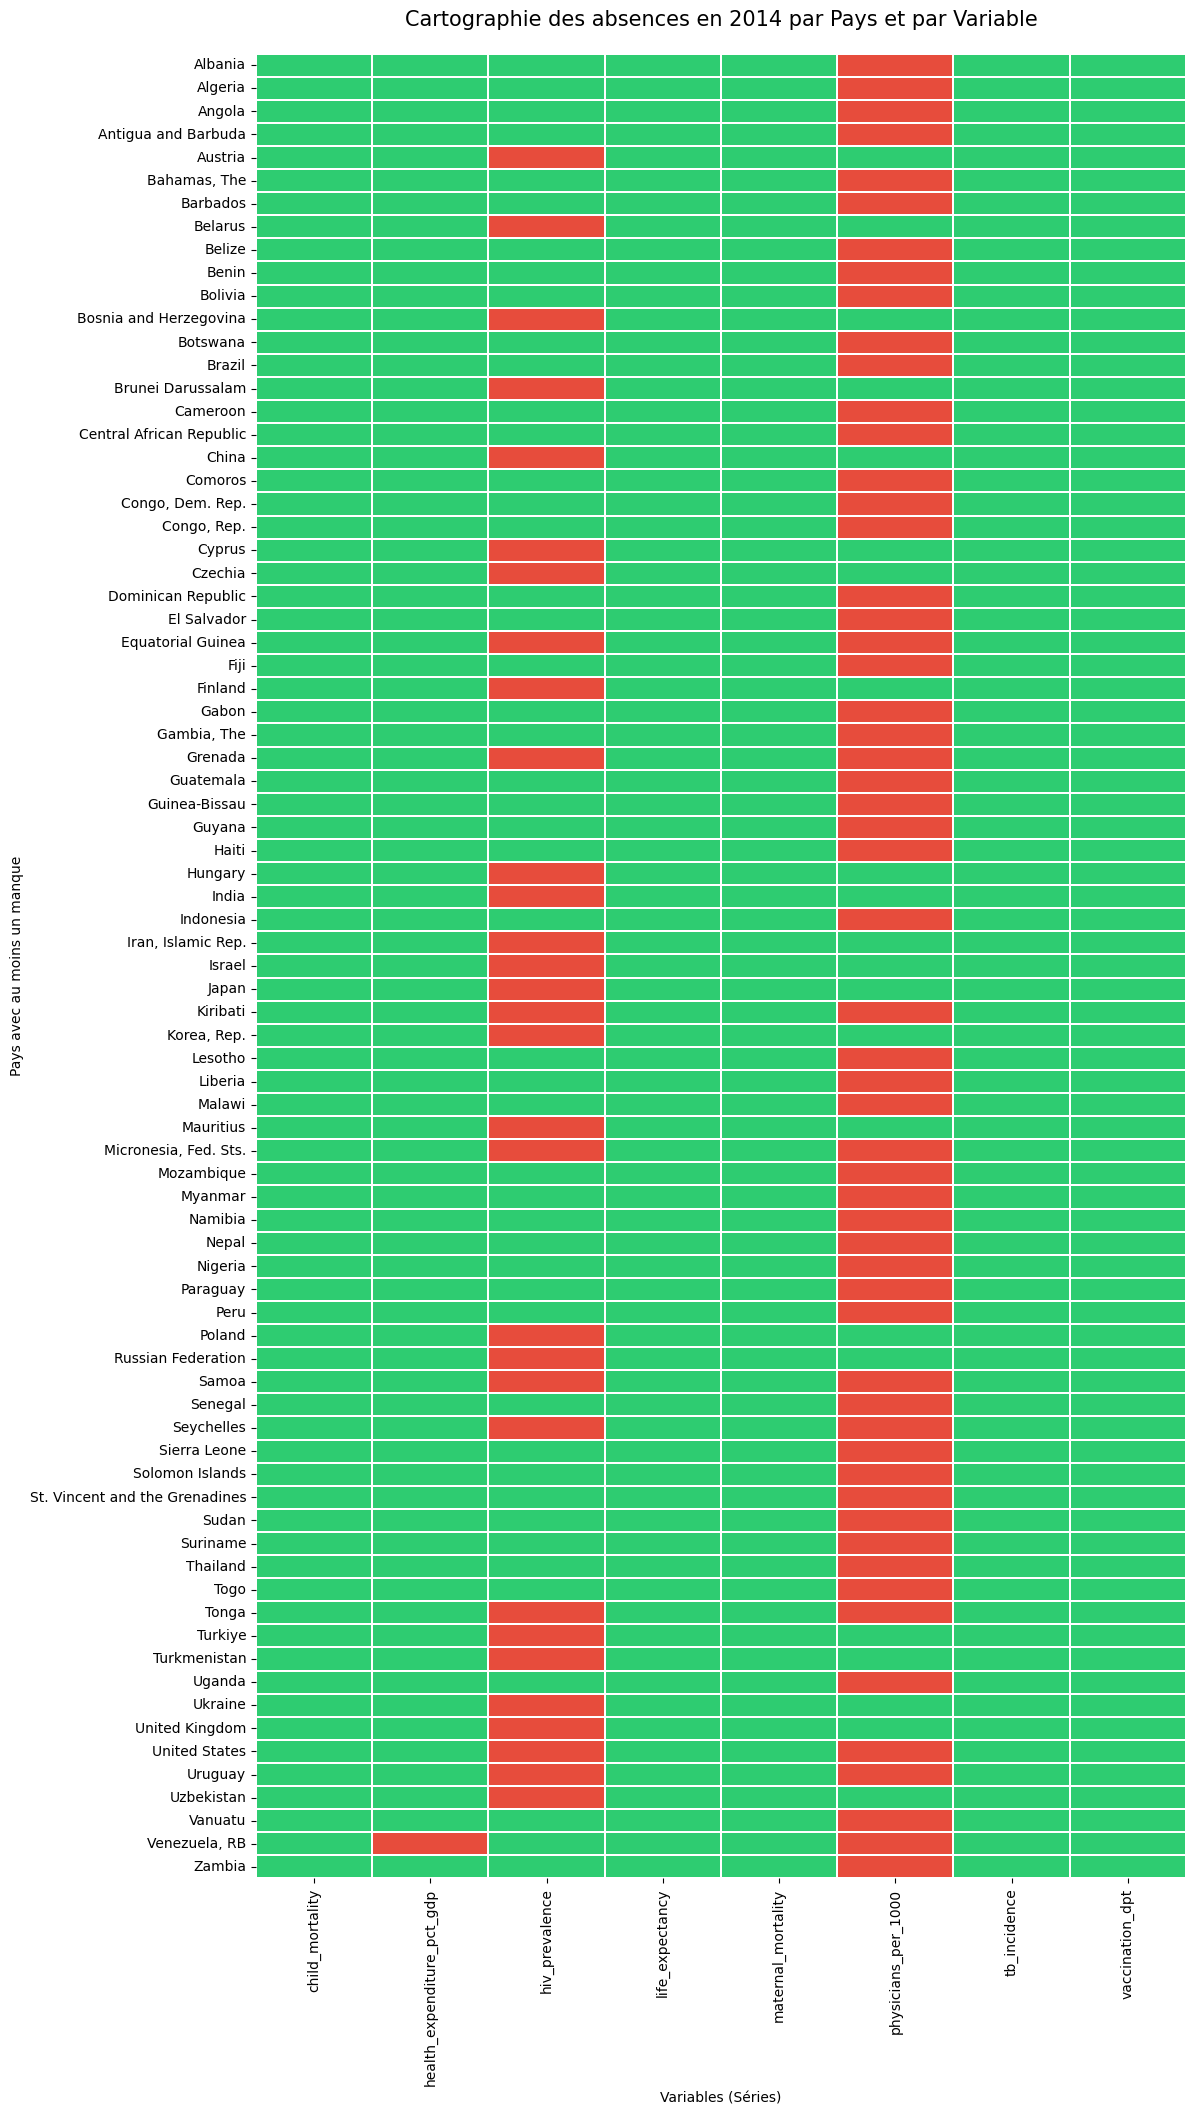

In [181]:
# Pivot pour avoir les Series en colonnes et les Countries en lignes
df_pivot_2014 = df_2014.pivot(index='Country', columns='Series', values='is_na')

# On ne garde que les pays qui ont au moins un NA
df_na_only = df_pivot_2014[df_pivot_2014.any(axis=1)]

plt.figure(figsize=(12, max(10, len(df_na_only) * 0.3)))
sns.heatmap(df_na_only, cmap=['#2ecc71', '#e74c3c'], cbar=False, linewidths=0.1)

# Légende personnalisée : Vert = Donnée présente, Rouge = NA
plt.title("Cartographie des absences en 2014 par Pays et par Variable", fontsize=15, pad=20)
plt.xlabel("Variables (Séries)")
plt.ylabel("Pays avec au moins un manque")
plt.show()

>Le taux de médecins (physicians_per_1000) a 34.1% de NA en 2014. 
Vérifions si élargir la fenêtre  permet de récupérer ces pays.

### Recherche sur 2015-2017

Pourquoi 2015-2017 ? car sont les plus proche de 2014 et le dataset demarre à 2014

In [182]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# Conversion numérique sécurisée pour les colonnes cibles
years = ['YR2014', 'YR2015', 'YR2016', 'YR2017']
for yr in years:
    df_wdi[yr] = pd.to_numeric(df_wdi[yr], errors='coerce')

# Identification des NA avant traitement
initial_na = df_wdi['YR2014'].isna()

# Application du Backfilling (2015 -> 2016 -> 2017)
# combine_first remplit uniquement si la valeur à gauche est NaN
df_wdi['YR2014'] = df_wdi['YR2014'].fillna(df_wdi['YR2015']) \
                                   .fillna(df_wdi['YR2016']) \
                                   .fillna(df_wdi['YR2017'])

# Encodage du statut : 0 = Original, 1 = Récupéré, 2 = Absent
df_wdi['status'] = 0
# Si c'était NA au début ET que ce n'est plus NA maintenant -> Récupéré
df_wdi.loc[initial_na & df_wdi['YR2014'].notna(), 'status'] = 1
# Si c'est toujours NA -> Absent
df_wdi.loc[df_wdi['YR2014'].isna(), 'status'] = 2

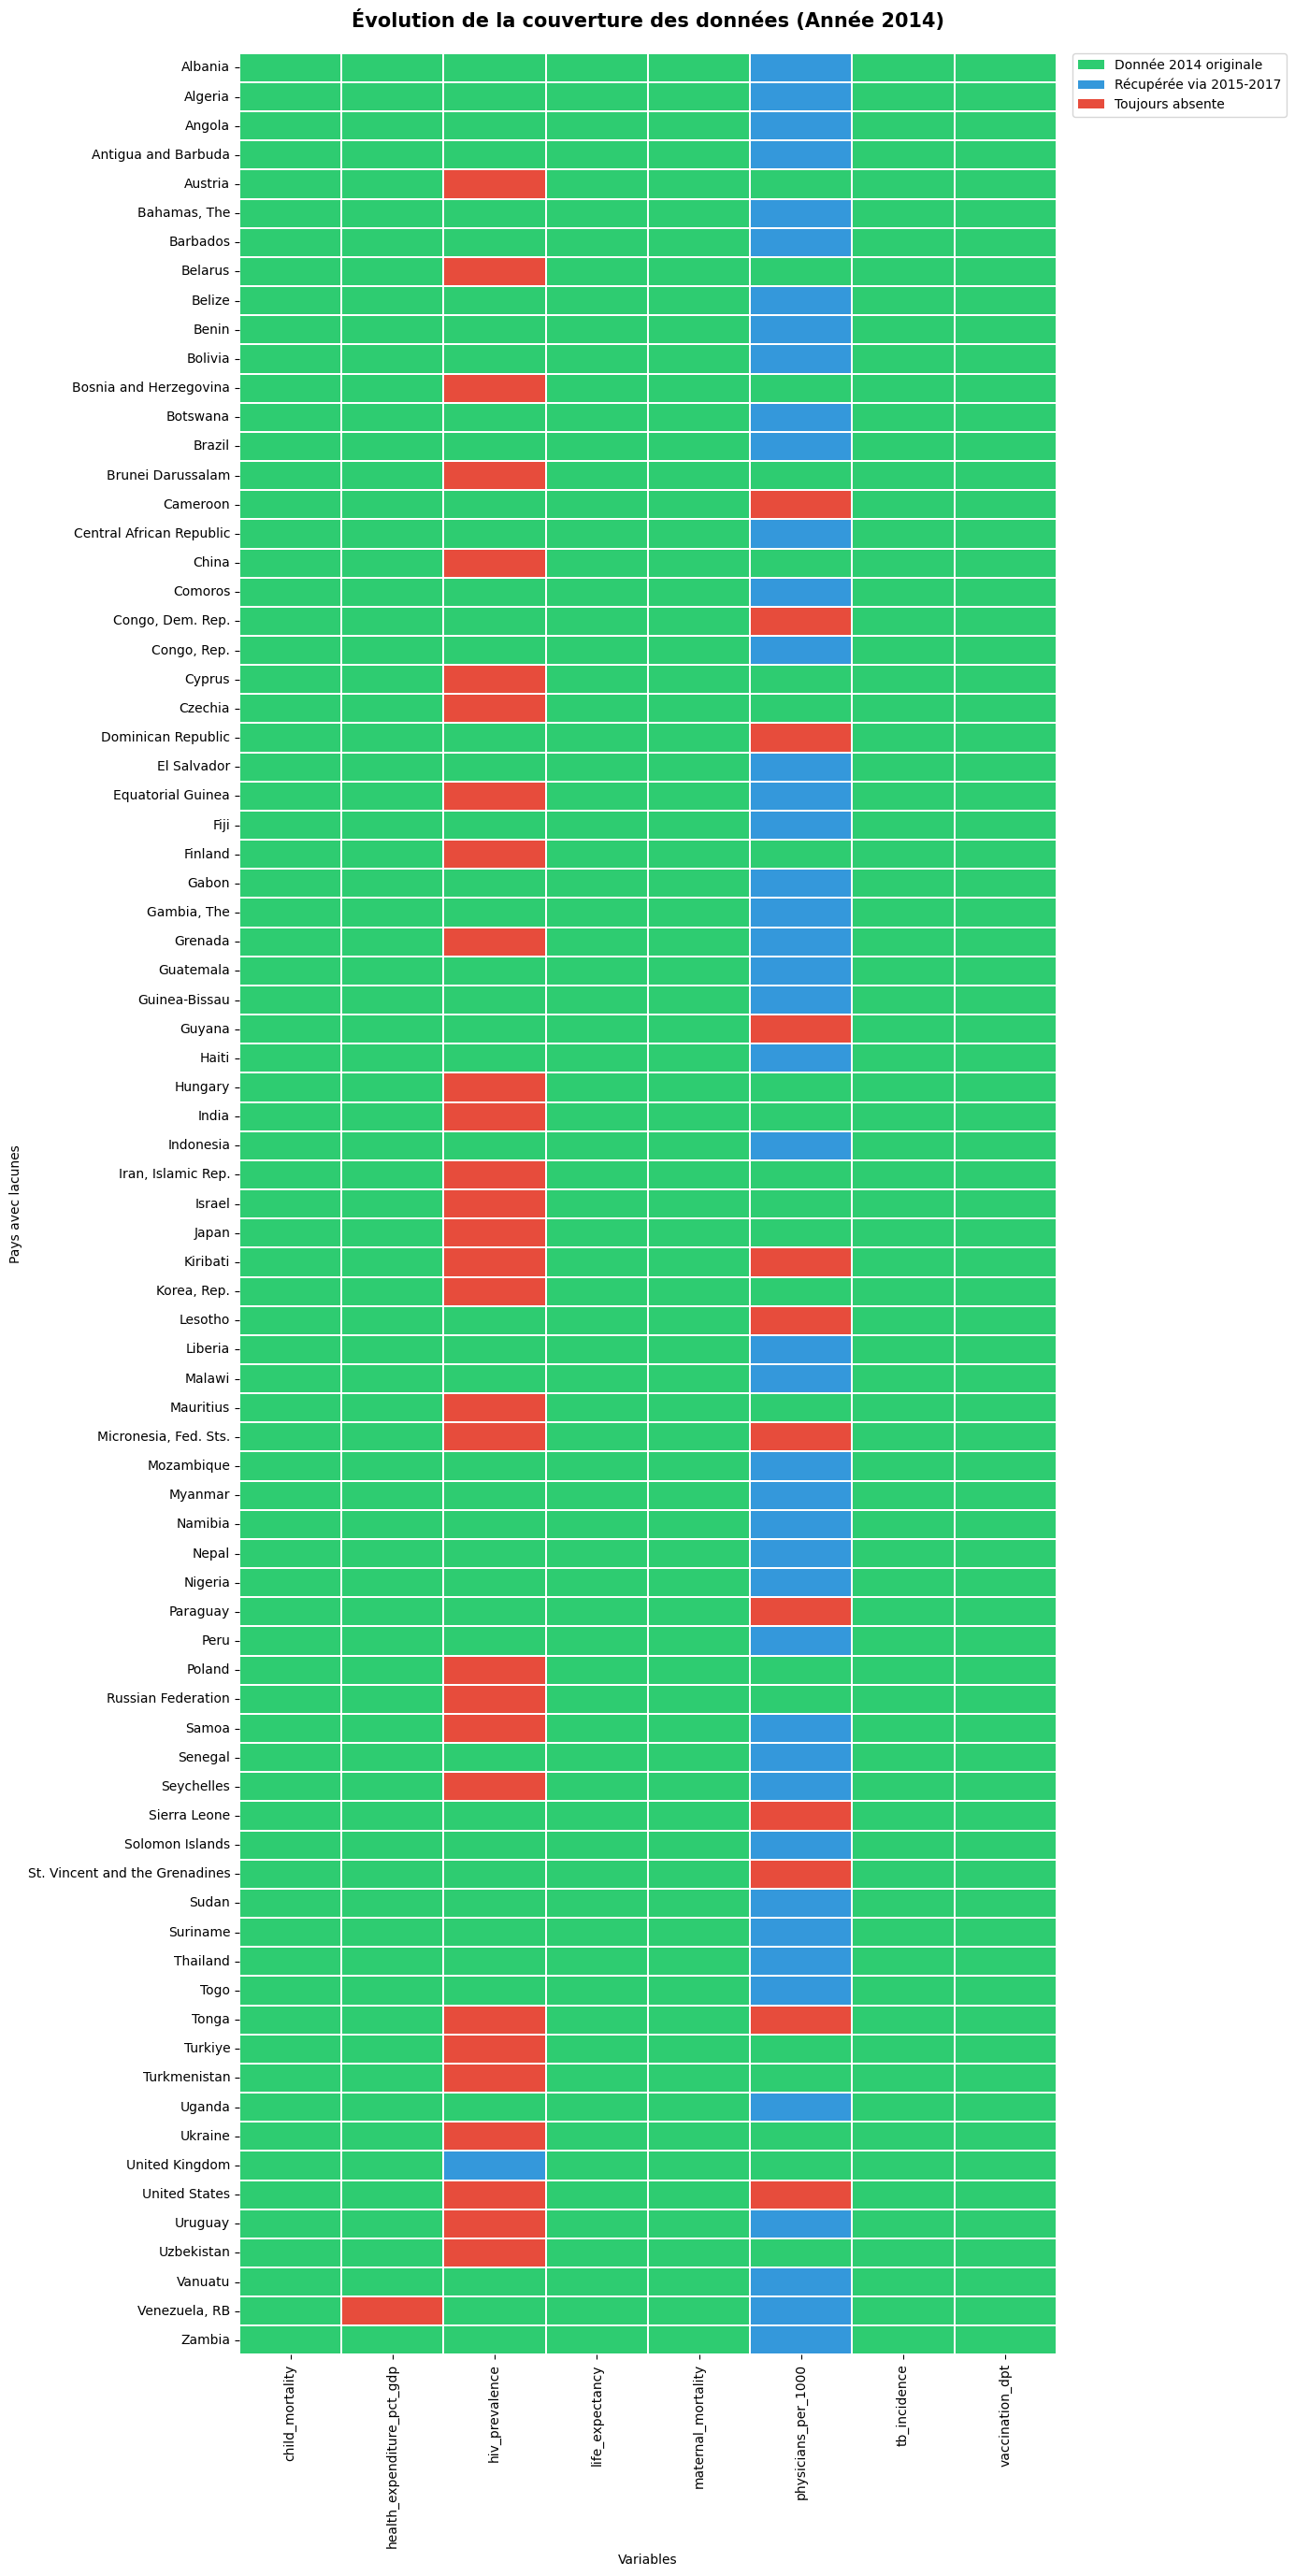

In [183]:
# On pivote le statut pour voir la provenance de chaque donnée
df_pivot_status = df_wdi.pivot(index='Country', columns='Series', values='status')

# Filtrage : On ne garde que les pays qui posaient problème (au moins un NA initial ou final)
df_viz = df_pivot_status[df_pivot_status.max(axis=1) > 0]

# Création de la figure
plt.figure(figsize=(14, max(8, len(df_viz) * 0.35)))

# Palette stricte : Vert (Présent), Bleu (Récupéré), Rouge (NA)
# Le paramètre vmin/vmax assure que 0=Vert, 1=Bleu, 2=Rouge même s'il manque une catégorie
colors = ["#2ecc71", "#3498db", "#e74c3c"]
sns.heatmap(df_viz, cmap=colors, cbar=False, linewidths=0.1, vmin=0, vmax=2)

# Légende
legend_elements = [
    Patch(facecolor='#2ecc71', label='Donnée 2014 originale'),
    Patch(facecolor='#3498db', label='Récupérée via 2015-2017'),
    Patch(facecolor='#e74c3c', label='Toujours absente')
]

plt.legend(handles=legend_elements, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.title("Évolution de la couverture des données (Année 2014)", fontsize=15, weight='bold', pad=20)
plt.ylabel("Pays avec lacunes")
plt.xlabel("Variables")
plt.tight_layout()
plt.show()

Certains NA sont toujours persistant,a examiner par EDA

### Merge


In [184]:
df_h14_pivot = df_wdi.pivot(index='iso_code', columns='Series', values='YR2014').reset_index()

#  Fusion  sur la clé iso_code
# On ne prend que les colonnes nécessaires pour éviter les doublons de noms de pays
df_final = df_final.merge(df_h14_pivot, on="iso_code", how="left")

#  Nettoyage final : suppression des colonnes techniques si elles existent
df_final = df_final.loc[:, ~df_final.columns.str.contains('^Unnamed|_y')]

df_final.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,iso_code,child_mortality,health_expenditure_pct_gdp,hiv_prevalence,life_expectancy,maternal_mortality,physicians_per_1000,tb_incidence,vaccination_dpt
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,AFG,74.6,9.528878,0.1,62.260,755.0,0.304,197.0,62.0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,ALB,9.9,6.358841,0.1,78.029,10.0,1.212,16.0,99.0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,DZA,25.4,6.014841,0.1,74.992,80.0,1.819,80.0,95.0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,AGO,64.5,2.156800,1.8,60.396,262.0,0.212,451.0,55.0
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,ATG,11.2,5.322183,0.9,76.912,32.0,2.917,3.4,99.0


In [185]:
na_counts = df_final.isnull().sum()

countries_with_na = df_final[df_final.isnull().any(axis=1)]['country'].nunique()

print("--- État des lieux post-récupération et post-merge ---")
print(f"Nombre total de pays avec au moins un NA : {countries_with_na}")
print("\nDétail des NA par indicateur :")
print(na_counts[na_counts > 0])

--- État des lieux post-récupération et post-merge ---
Nombre total de pays avec au moins un NA : 39

Détail des NA par indicateur :
health_expenditure_pct_gdp     1
hiv_prevalence                30
physicians_per_1000           12
dtype: int64


# Santé who datasets

In [186]:
who_conf = sources["sante_who"]
df_who = pd.read_csv(raw_dir / who_conf["file"])
df_who.head(2)


,country_code,year,life_expectancy_who
0,TZA,2018,64.792958
1,DEU,2014,80.759927


La variable "life_expectancy" est deja capté dans sa version wdi,l'information existe et même dans le dataset originel elle y est donc j'estime a ce stade que on peux s'en passer.

#  Pauvreté, Nutrition, Social dataset

Ces pays existent belle et bien mais sous des noms legerement differents
> En ouvrant l'un de ces dataset,on constate quelques erreurs dans les code ISO notament ceux du congo (decallage). Le plus simple ici serais de merger via nom des pays et de trouver une solution  hadock pour les cas problématiques.

In [187]:
# Enrichissement du dictionnaire avec les variantes orthographiques des sources sociales
wdi_to_iso_final.update({
    "Congo": "COD",
    "Micronesia": "FSM",
    "Korea": "KOR"
})

In [188]:
social_keys = ["social_poverty_mpi", "social_literacy", "social_poverty_2_15", "social_schooling", "social_undernourishment"]
df_social = pd.DataFrame(index=df_final['iso_code'].unique())

for key in social_keys:
    conf = sources[key]
    df_tmp = pd.read_excel(raw_dir / conf["file"])
    
    # Nettoyage des noms et identification des occurrences multiples pour le Congo
    df_tmp['Country Name'] = df_tmp['Country Name'].astype(str).str.strip()
    congo_mask = df_tmp['Country Name'] == 'Congo'
    
    # Attribution forcée basée sur l'ordre des lignes identifié lors de l'inspection
    # On assigne COD à la première occurrence et COG à la seconde
    df_tmp.loc[df_tmp[congo_mask].index[0], 'iso_code'] = 'COD'
    df_tmp.loc[df_tmp[congo_mask].index[1], 'iso_code'] = 'COG'
    
    # Application du dictionnaire de secours pour les autres pays
    mask_no_iso = df_tmp['iso_code'].isna()
    df_tmp.loc[mask_no_iso, 'iso_code'] = df_tmp.loc[mask_no_iso, 'Country Name'].map(wdi_to_iso_final)
    
    # Application de la fonction générique pour les pays restants
    mask_still_no_iso = df_tmp['iso_code'].isna()
    df_tmp.loc[mask_still_no_iso, 'iso_code'] = df_tmp.loc[mask_still_no_iso, 'Country Name'].apply(get_iso_code)
    
    # Définition de l'index et suppression des doublons ISO pour la jointure
    df_tmp = df_tmp.drop_duplicates(subset='iso_code').set_index("iso_code")
    
    # Extraction des colonnes temporelles
    years = [c for c in df_tmp.columns if isinstance(c, int) or (isinstance(c, str) and c.isdigit())]
    
    # Intégration au référentiel par jointure gauche
    df_to_merge = df_tmp[years].add_prefix(f"{key}_")
    df_social = df_social.join(df_to_merge, how='left')

# Vérification finale de la complétude
missing_final = df_social.index[df_social.isna().all(axis=1)].tolist()
print(f"Nombre de pays orphelins : {len(missing_final)}")

Nombre de pays orphelins : 0


## NA valeurs

### Description

Bilan des valeurs manquantes par indicateur social en 2014 :
                              Nombre de NA  Proportion de NA (%)
social_poverty_mpi_2014              162.0                  97.0
social_literacy_2014                 137.0                  82.0
social_poverty_2_15_2014              88.0                  52.7
social_schooling_2014                 51.0                  30.5
social_undernourishment_2014          18.0                  10.8


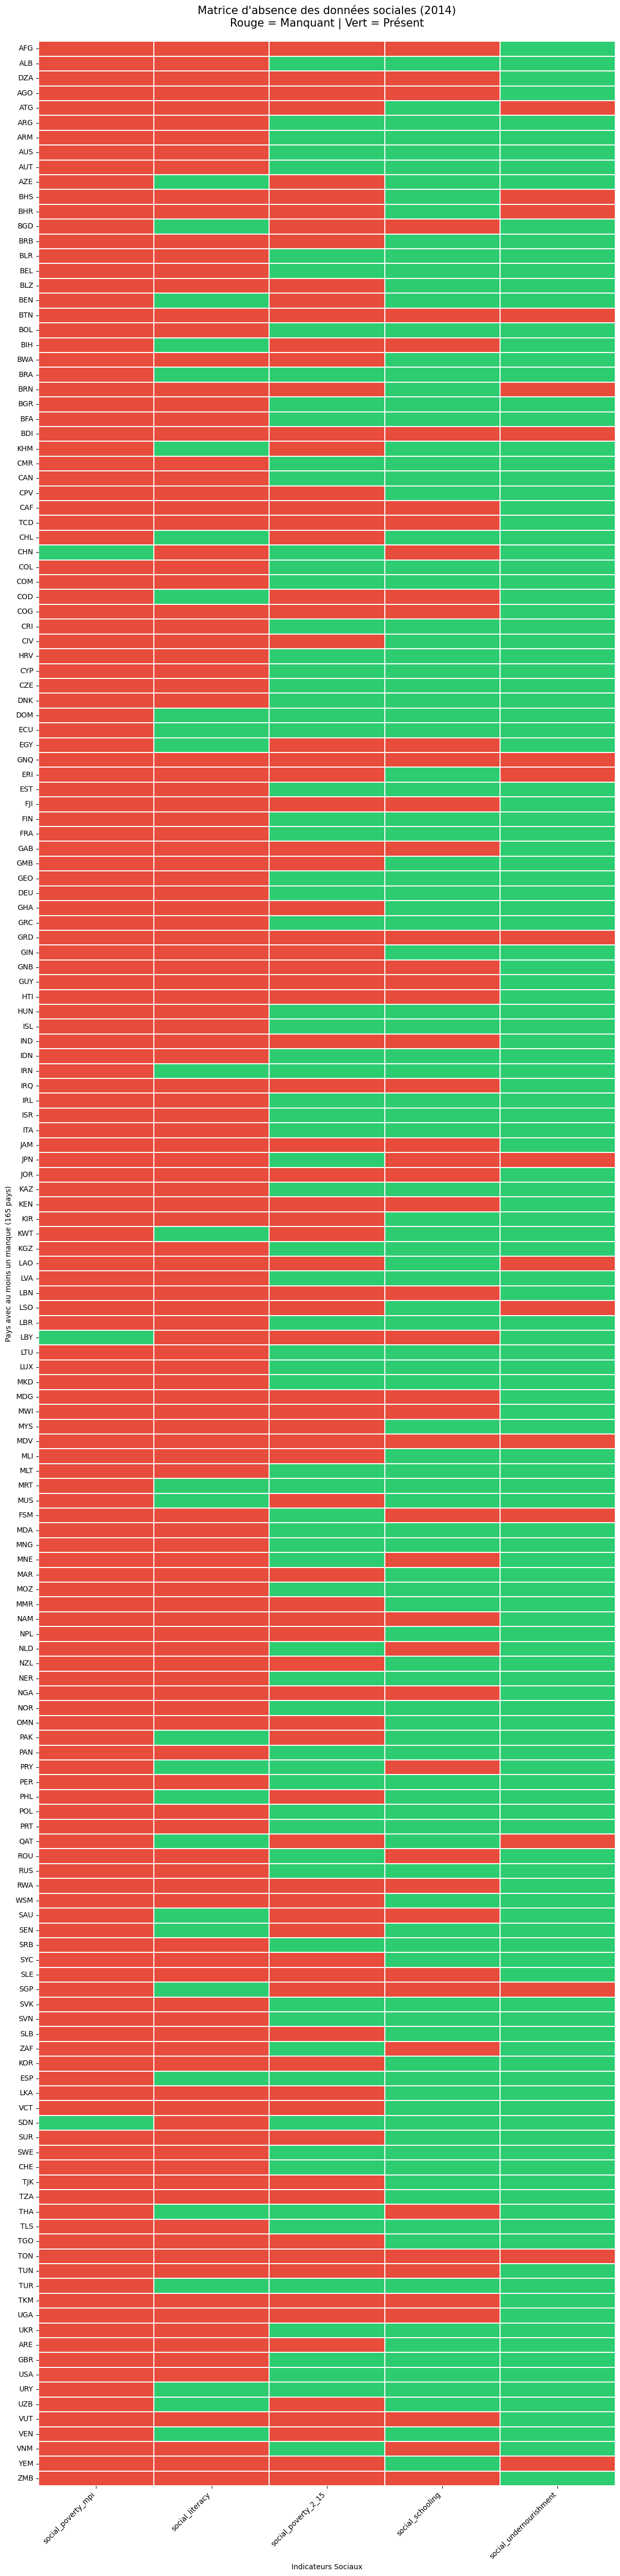

In [189]:
# Extraction des colonnes spécifiques à l'année 2014 pour le bloc social
cols_2014 = [c for c in df_social.columns if c.endswith('_2014')]
df_social_2014 = df_social[cols_2014].copy()

# Création de la matrice booléenne des manquants (True si NA)
df_na_matrix = df_social_2014.isna()

# Statistiques descriptives par indicateur
stats_na = df_na_matrix.agg(['sum', 'mean']).T
stats_na.columns = ['Nombre de NA', 'Proportion de NA']
stats_na['Proportion de NA (%)'] = (stats_na['Proportion de NA'] * 100).round(1)

print("Bilan des valeurs manquantes par indicateur social en 2014 :")
print(stats_na[['Nombre de NA', 'Proportion de NA (%)']])

# Préparation des données pour la visualisation
# On ne conserve que les pays présentant au moins une valeur manquante
df_heat = df_na_matrix[df_na_matrix.any(axis=1)]

# Traduction des noms de colonnes pour plus de clarté sur le graphique
df_heat.columns = [c.replace('_2014', '') for c in df_heat.columns]

# Visualisation par carte de chaleur (Heatmap)
plt.figure(figsize=(12, max(8, len(df_heat) * 0.3)))
sns.heatmap(df_heat, cmap=['#2ecc71', '#e74c3c'], cbar=False, linewidths=0.1)

plt.title("Matrice d'absence des données sociales (2014)\nRouge = Manquant | Vert = Présent", fontsize=15, pad=20)
plt.xlabel("Indicateurs Sociaux")
plt.ylabel(f"Pays avec au moins un manque ({len(df_heat)} pays)")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Recherche 2010-2018
Pourquoi 2010-2018 ? Car la plage temporelle est tres grande et surtout le dataset a pleins de NA

In [190]:
# Préparation d'un dictionnaire pour stocker les nouvelles colonnes
status_data = {}
consolidated_2014 = {}

for key in social_keys:
    col_2014 = f"{key}_2014"
    
    # Capture de l'état initial des NA
    initial_na = df_social[col_2014].isna()
    
    # Travail sur une copie locale pour éviter les modifications itératives sur df_social
    series_2014 = df_social[col_2014].copy()
    
    search_years = [2015, 2013, 2016, 2012, 2017, 2011, 2018, 2010]
    
    for yr in search_years:
        col_yr = f"{key}_{yr}"
        if col_yr in df_social.columns:
            series_2014 = series_2014.fillna(df_social[col_yr])
            
    # Stockage de la série consolidée
    consolidated_2014[col_2014] = series_2014
    
    # Détermination du statut (0: Original, 1: Récupéré, 2: Absent)
    status = pd.Series(0, index=df_social.index)
    status.loc[initial_na & series_2014.notna()] = 1
    status.loc[series_2014.isna()] = 2
    status_data[f"{key}_status"] = status

# Création de DataFrames temporaires pour une concaténation unique
df_status = pd.DataFrame(status_data)
df_social_final = pd.DataFrame(consolidated_2014)

# Mise à jour de df_social en une seule opération pour éviter la fragmentation
df_social = pd.concat([df_social, df_status], axis=1)

# Nettoyage des noms pour le DataFrame final
df_social_final.columns = social_keys

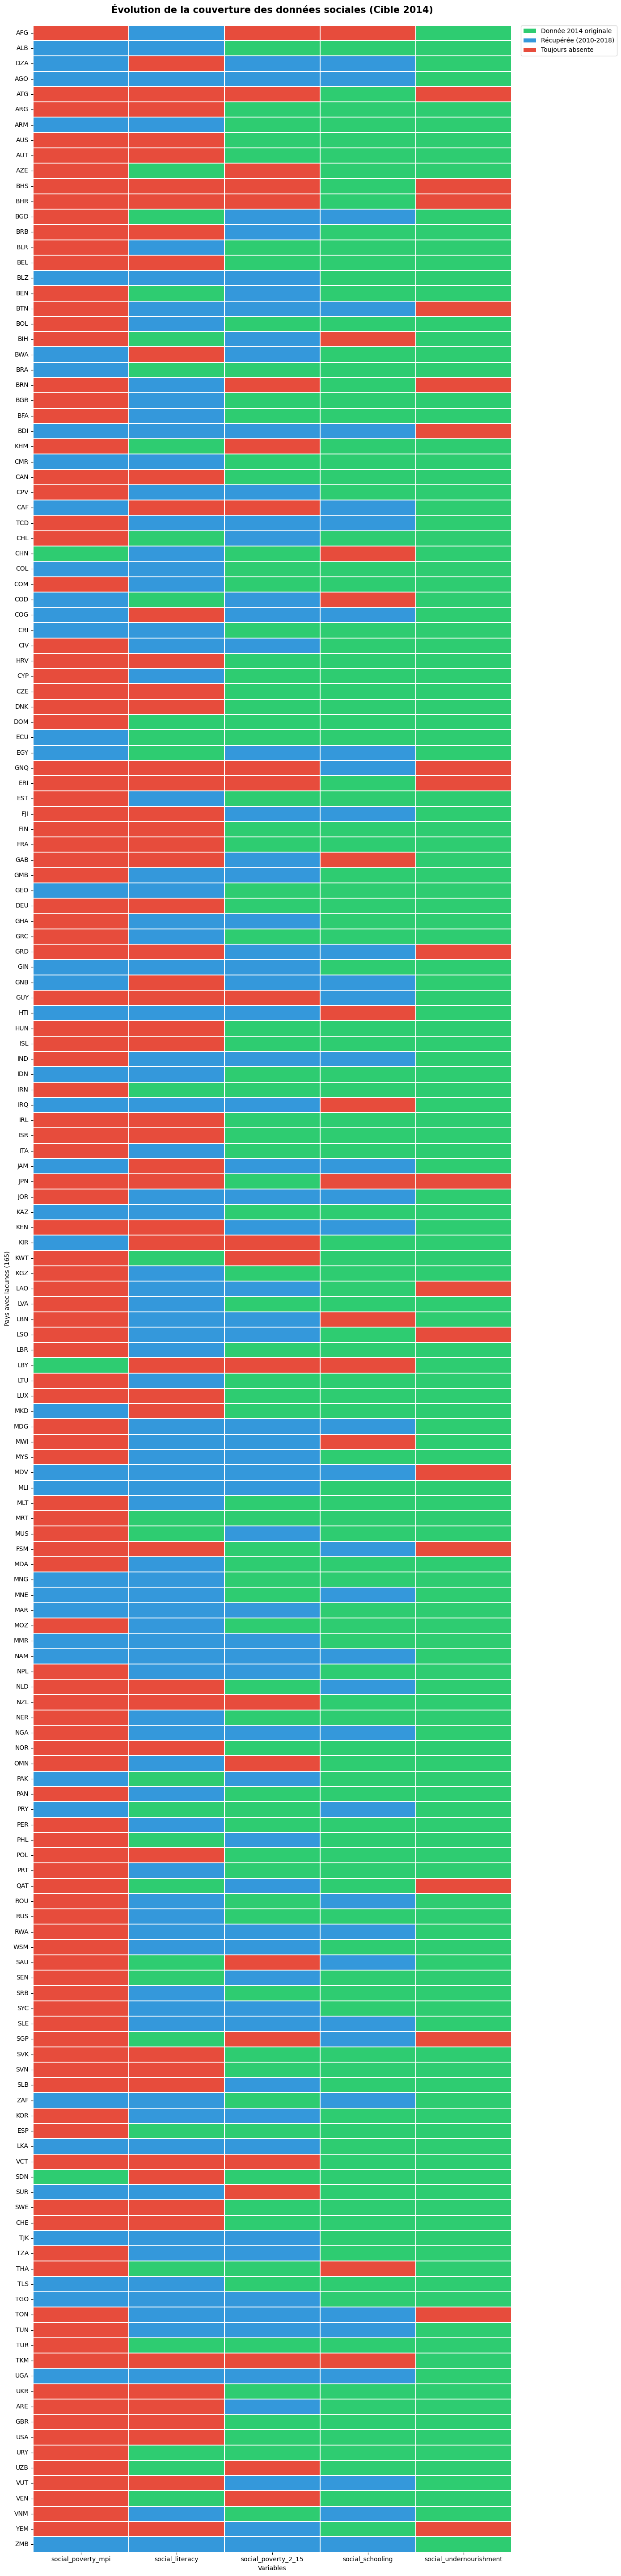

In [191]:
# Sélection rigoureuse des colonnes de statut créées dans le dictionnaire status_data
# Cela garantit d'avoir exactement len(social_keys) colonnes
status_cols = [f"{key}_status" for key in social_keys]

# Vérification de l'existence des colonnes avant extraction
available_status_cols = [c for c in status_cols if c in df_social.columns]
df_viz = df_social[available_status_cols].copy()

# Renommage pour la clarté des axes sur la heatmap
# On utilise un dictionnaire de mapping pour éviter l'erreur de longueur (ValueError)
rename_map = {f"{key}_status": key for key in social_keys}
df_viz = df_viz.rename(columns=rename_map)

# Filtrage : pays ayant au moins une donnée récupérée (1) ou absente (2)
df_viz = df_viz[df_viz.max(axis=1) > 0]

# Création de la figure
plt.figure(figsize=(14, max(8, len(df_viz) * 0.35)))

# Palette de couleurs : Vert (Original), Bleu (Récupéré), Rouge (Absent)
colors = ["#2ecc71", "#3498db", "#e74c3c"]
sns.heatmap(df_viz, cmap=colors, cbar=False, linewidths=0.1, vmin=0, vmax=2)

# Légende
legend_elements = [
    Patch(facecolor='#2ecc71', label='Donnée 2014 originale'),
    Patch(facecolor='#3498db', label='Récupérée (2010-2018)'),
    Patch(facecolor='#e74c3c', label='Toujours absente')
]

plt.legend(handles=legend_elements, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.title("Évolution de la couverture des données sociales (Cible 2014)", fontsize=15, weight='bold', pad=20)
plt.ylabel(f"Pays avec lacunes ({len(df_viz)})")
plt.xlabel("Variables")

plt.tight_layout()
plt.show()

### Merge

In [192]:
# 1. Préparation de la partie droite (sociale)
# On s'assure que l'index est bien nommé 'iso_code' avant le reset
df_social_final.index.name = 'iso_code'
df_social_to_merge = df_social_final.reset_index()

# 2. Vérification de la partie gauche (référentiel)
# Si iso_code est dans l'index de df_final, on le descend en colonne
if 'iso_code' not in df_final.columns:
    df_final = df_final.reset_index()

# 3. Fusion rigoureuse
# On spécifie explicitement les colonnes pour éviter toute ambiguïté
df_final = df_final.merge(df_social_to_merge, on="iso_code", how="left")

# 4. Nettoyage des suffixes et colonnes parasites
df_final = df_final.loc[:, ~df_final.columns.str.contains('^Unnamed|_y$')]

# Affichage du résultat pour confirmation
print(f"Nombre de pays : {len(df_final)}")
print(f"Colonnes actuelles : {df_final.columns.tolist()}")
df_final.head()

Nombre de pays : 167
Colonnes actuelles : ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp', 'iso_code', 'child_mortality', 'health_expenditure_pct_gdp', 'hiv_prevalence', 'life_expectancy', 'maternal_mortality', 'physicians_per_1000', 'tb_incidence', 'vaccination_dpt', 'social_poverty_mpi', 'social_literacy', 'social_poverty_2_15', 'social_schooling', 'social_undernourishment']


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,...,life_expectancy,maternal_mortality,physicians_per_1000,tb_incidence,vaccination_dpt,social_poverty_mpi,social_literacy,social_poverty_2_15,social_schooling,social_undernourishment
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,...,62.260,755.0,0.304,197.0,62.0,NaN,33.750000,NaN,NaN,19.3
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,...,78.029,10.0,1.212,16.0,99.0,0.7,97.250000,3.7,93.78369,4.6
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,...,74.992,80.0,1.819,80.0,95.0,1.4,NaN,0.0,97.54838,2.7
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,...,60.396,262.0,0.212,451.0,55.0,51.1,66.029999,39.3,78.02393,13.2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,...,76.912,32.0,2.917,3.4,99.0,NaN,NaN,NaN,91.88907,NaN


Bilan de la complétude des variables sociales (après consolidation) :
                         Nombre de NA  Proportion de NA (%)
social_poverty_mpi              119.0                 71.26
social_literacy                  56.0                 33.53
social_poverty_2_15              23.0                 13.77
social_undernourishment          18.0                 10.78
social_schooling                 13.0                  7.78


C:\Users\HP\AppData\Local\Temp\ipykernel_3652\262969983.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stats_na_final['Proportion de NA (%)'], y=stats_na_final.index, palette='Reds_r')


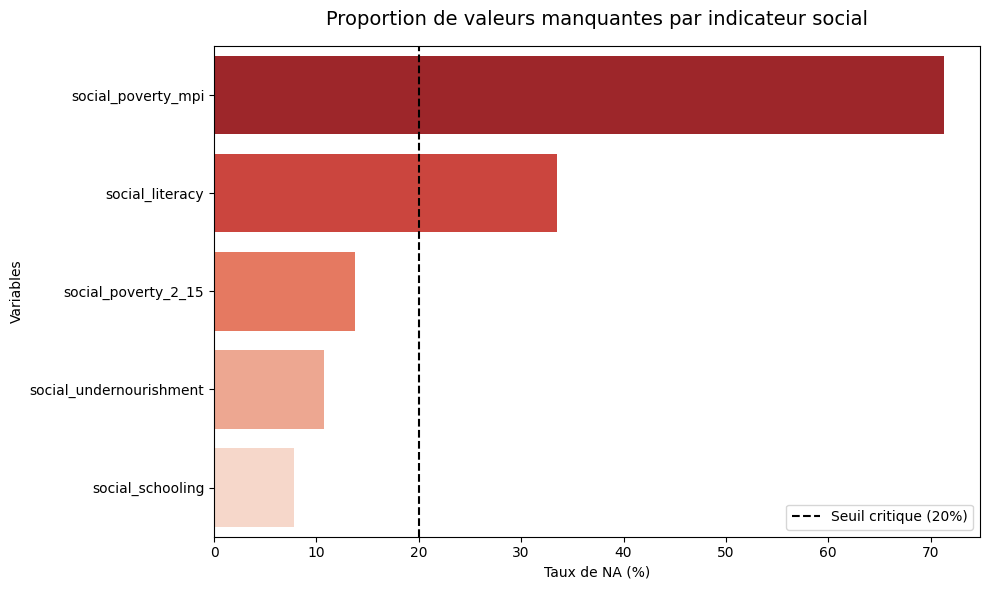

In [193]:
# Identification des colonnes sociales intégrées (social_keys)
# On calcule le nombre et la proportion de NA pour chaque variable
stats_na_final = df_final[social_keys].isna().agg(['sum', 'mean']).T
stats_na_final.columns = ['Nombre de NA', 'Proportion de NA']

# Formatage pour une lecture académique
stats_na_final['Proportion de NA (%)'] = (stats_na_final['Proportion de NA'] * 100).round(2)
stats_na_final = stats_na_final.sort_values(by='Nombre de NA', ascending=False)

print("Bilan de la complétude des variables sociales (après consolidation) :")
print(stats_na_final[['Nombre de NA', 'Proportion de NA (%)']])

# Représentation graphique de la structure des manques
plt.figure(figsize=(10, 6))
sns.barplot(x=stats_na_final['Proportion de NA (%)'], y=stats_na_final.index, palette='Reds_r')

# Seuil critique de 20% (limite usuelle pour l'imputation statistique)
plt.axvline(x=20, color='black', linestyle='--', label='Seuil critique (20%)')

plt.title("Proportion de valeurs manquantes par indicateur social", fontsize=14, pad=15)
plt.xlabel("Taux de NA (%)")
plt.ylabel("Variables")
plt.legend()
plt.tight_layout()
plt.show()

# Sécurité et Conflits


Nous allons procéder à une unification des données de sécurité en agrégeant, pour chaque fichier source, les segments issus des feuilles Non_HRP, HRP_1 et HRP_2. Cette démarche vise à supprimer le biais d'exclusion identifié précédemment (...), en réintégrant les pays sous plan de réponse humanitaire (HRP) qui concentrent l'essentiel de l'instabilité mondiale. L'approche repose sur la concaténation de ces strates avant d'appliquer une résolution ISO rigoureuse, garantissant que chaque pays du référentiel des 167 nations soit correctement documenté ou, à défaut, identifié comme une zone sans conflit observé.

In [194]:
# Enrichissement du dictionnaire de secours et initialisation
# On procéde ainsi car la feuille Non-HRP n'a de ISO code3
acled_to_iso = {
    'Russia': 'RUS', 'Ivory Coast': 'CIV', 'Cape Verde': 'CPV', 
    'Republic of Congo': 'COG', 'East Timor': 'TLS', 'Brunei': 'BRN', 'Kosovo': 'XKX',"Democratic Republic of Congo":"COD"
}
wdi_to_iso_final.update(acled_to_iso)

df_security = pd.DataFrame(index=df_final['iso_code'].unique())
sec_keys = ["securite_civil", "securite_political"]
tabs = ["Non_HRP", "HRP_1", "HRP_2"]

for key in sec_keys:
    conf = sources[key]
    all_tabs_data = []
    
    # Lecture itérative des feuilles disponibles pour chaque source
    for tab in tabs:
        try:
            df_tab = pd.read_excel(raw_dir / conf["file"], sheet_name=tab)
            all_tabs_data.append(df_tab)
        except ValueError:
            # Gestion du cas où une feuille spécifique serait absente d'un fichier
            pass
            
    # Unification des segments de données
    df_tmp = pd.concat(all_tabs_data, ignore_index=True)
    df_tmp['Country'] = df_tmp['Country'].astype(str).str.strip()
    
    # Résolution ISO multiniveau : dictionnaire puis fonction générique
    df_tmp['iso_code'] = df_tmp['Country'].map(wdi_to_iso_final)
    mask = df_tmp['iso_code'].isna()
    df_tmp.loc[mask, 'iso_code'] = df_tmp.loc[mask, 'Country'].apply(get_iso_code)
    
    # Agrégation temporelle et métrique (Sommation des événements et décès)
    for metric in ["Events", "Fatalities"]:
        df_pivot = df_tmp.pivot_table(index='iso_code', columns='Year', values=metric, aggfunc='sum')
        df_pivot = df_pivot.add_prefix(f"{key}_{metric}_")
        
        # Jonction au conteneur principal
        df_security = df_security.join(df_pivot, how='left')

In [195]:
# Audit de l'intégrité et de la complétude du bloc sécurité
# Les NaN sont conservés pour identifier les échecs de matching ISO

print(f"Dimensions du bloc consolidé : {df_security.shape}")

# Identification des pays n'ayant matché sur aucun onglet (orphelins techniques)
orphelins_techniques = df_security.index[df_security.isna().all(axis=1)].tolist()
print(f"Nombre de pays non réconciliés : {len(orphelins_techniques)}")
print(f"Liste des ISO en échec : {orphelins_techniques}")

# Diagnostic de densité pour l'année pivot 2014
cols_2014 = [c for c in df_security.columns if c.endswith('_2014')]
print(f"Variables 2014 identifiées : {cols_2014}")

# Vérification de l'existence de données pour les zones critiques
# Un résultat vide ou contenant des NaN ici signalerait un problème de source
target_check = ['AFG', 'COD', 'UKR']
print("Aperçu des données pour les pays témoins (2014) :")
print(df_security.loc[df_security.index.isin(target_check), cols_2014])

Dimensions du bloc consolidé : (167, 120)
Nombre de pays non réconciliés : 0
Liste des ISO en échec : []
Variables 2014 identifiées : ['securite_civil_Events_2014', 'securite_civil_Fatalities_2014', 'securite_political_Events_2014', 'securite_political_Fatalities_2014']
Aperçu des données pour les pays témoins (2014) :
     securite_civil_Events_2014  securite_civil_Fatalities_2014  \
AFG                         NaN                             NaN   
COD                       369.0                           588.0   
UKR                         NaN                             NaN   

     securite_political_Events_2014  securite_political_Fatalities_2014  
AFG                             NaN                                 NaN  
COD                           750.0                              1205.0  
UKR                             NaN                                 NaN  


In [197]:
df_security.head()

,securite_civil_Events_1997,securite_civil_Events_1998,securite_civil_Events_1999,securite_civil_Events_2000,securite_civil_Events_2001,securite_civil_Events_2002,securite_civil_Events_2003,securite_civil_Events_2004,securite_civil_Events_2005,securite_civil_Events_2006,...,securite_political_Fatalities_2017,securite_political_Fatalities_2018,securite_political_Fatalities_2019,securite_political_Fatalities_2020,securite_political_Fatalities_2021,securite_political_Fatalities_2022,securite_political_Fatalities_2023,securite_political_Fatalities_2024,securite_political_Fatalities_2025,securite_political_Fatalities_2026
AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,36350.0,42987.0,41419.0,31029.0,42421.0,4152.0,1152.0,1363.0,918.0,559.0
ALB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
DZA,132.0,33.0,31.0,69.0,56.0,93.0,49.0,27.0,11.0,39.0,...,143.0,63.0,21.0,32.0,25.0,27.0,13.0,35.0,32.0,24.0
AGO,51.0,107.0,103.0,69.0,119.0,7.0,0.0,3.0,0.0,2.0,...,67.0,41.0,23.0,70.0,149.0,104.0,57.0,98.0,169.0,12.0
ATG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,0.0,2.0,0.0,0.0,1.0,3.0,1.0,0.0


## Valeurs NA

### Description

In [216]:
# 1. Isolation des colonnes 2014
cols_2014 = [c for c in df_security.columns if c.endswith('_2014')]
df_2014 = df_security[cols_2014]

# 2. Calcul des statistiques globales par variable
stats_global_2014 = pd.DataFrame({
    'Valeurs Présentes': df_2014.notna().sum(),
    'Valeurs Manquantes': df_2014.isna().sum(),
    'Taux de Vacuité (%)': (df_2014.isna().mean() * 100).round(2)
})

print("=== STATISTIQUES GLOBALES PAR VARIABLE (2014) ===")
print(stats_global_2014)
print("\n")

=== STATISTIQUES GLOBALES PAR VARIABLE (2014) ===
                                    Valeurs Présentes  Valeurs Manquantes  \
securite_civil_Events_2014                         52                 115   
securite_civil_Fatalities_2014                     52                 115   
securite_political_Events_2014                     52                 115   
securite_political_Fatalities_2014                 52                 115   

                                    Taux de Vacuité (%)  
securite_civil_Events_2014                        68.86  
securite_civil_Fatalities_2014                    68.86  
securite_political_Events_2014                    68.86  
securite_political_Fatalities_2014                68.86  




In [217]:
# 1. Calcul de la vacuité par pays (ligne)
df_country_na = df_2014.isna().sum(axis=1).to_frame(name='Nb_NA')
df_country_na['Taux_NA_Pays (%)'] = (df_country_na['Nb_NA'] / len(cols_2014) * 100).round(2)

# 2. Extraction du Top 15 des pays les plus incomplets
top_15_na = df_country_na.sort_values(by='Taux_NA_Pays (%)', ascending=False).head(15)

print("=== TOP 15 DES PAYS PAR TAUX DE NA (2014) ===")
print(top_15_na)

=== TOP 15 DES PAYS PAR TAUX DE NA (2014) ===
     Nb_NA  Taux_NA_Pays (%)
AFG      4             100.0
ALB      4             100.0
ATG      4             100.0
ARM      4             100.0
ARG      4             100.0
AUT      4             100.0
AUS      4             100.0
COL      4             100.0
COM      4             100.0
AZE      4             100.0
BHS      4             100.0
BHR      4             100.0
BRB      4             100.0
BLR      4             100.0
BEL      4             100.0


L'analyse des statistiques de l'année 2014 révèle une fragilité structurelle majeure de la base de données de sécurité, caractérisée par un taux de vacuité global de 68,86 % pour l'ensemble des indicateurs. Cette absence de données, parfaitement symétrique entre les variables civiles et politiques, démontre que la source utilisée n'opère pas un recensement mondial mais se limite à un périmètre restreint, probablement calqué sur les pays bénéficiant de plans de réponse humanitaire . L'examen du "Top 15 des pays par taux de NA" confirme cette hypothèse : des nations aux profils de risque radicalement opposés, tels que l'Afghanistan (pourtant en conflit ouvert en 2014) et la Belgique, partagent un taux d'omission de **100 %**. Cette situation indique que l'absence de données pour l'Afghanistan ou la Colombie ne résulte pas d'une absence de conflictualité, mais d'une exclusion de ces zones des feuilles de calcul sources.  un tel niveau d'attrition ($n=52$ pays renseignés sur 167) rend toute généralisation risquée et impose, soit une restriction de l'étude aux pays couverts par le système humanitaire, soit l'intégration d'une base de données complémentaire pour rétablir une représentativité géographique minimale.Elargissons la fenetre pour essayer de capter l'info.

En 2014, ACLED ne couvrait pas encore l’ensemble des pays du monde. Le projet s’est d’abord concentré sur l’Afrique, avant d’étendre progressivement sa couverture à l’Asie, au Moyen-Orient, puis plus tard à l’Europe, à l’Amérique latine et à l’Océanie. Ainsi, l’absence de données pour des pays comme Argentina ou Belgium en 2014 ne signifie pas l’absence d’événements violents, mais simplement que ces pays n’étaient pas encore inclus dans le périmètre d’observation d’ACLED à cette date.

Élargir la recherche à des années plus récentes afin de récupérer ces informations introduirait cependant une incohérence temporelle avec les autres variables de notre étude et surtout l'absence de donnée est en soit une information mais peux aussi signifier que ce pays n'est pas encore couvert,et une donnée de 2018 par exemple ne  reflete peut etre pas 2014. Une telle démarche risquerait de mélanger des contextes géopolitiques différents et de biaiser l’analyse comparative entre pays. Pour préserver l’homogénéité temporelle et la robustesse méthodologique du clustering, nous faisons donc le choix d’exclure ces variables issues d’ACLED de l’analyse finale.

# FIN

In [223]:

print(f"Taille finale : {df_final.shape}")
print(f"Nombre de pays : {df_final['country'].nunique()} (les 167 sont bien présents)")

output_path = paths.DATA_DIR / "merged_data.csv"
df_final.to_csv(output_path, index=False)
print(f"\n Fichier exporté avec succès dans : {output_path}")

display(df_final.head())

Taille finale : (167, 24)
Nombre de pays : 167 (les 167 sont bien présents)

 Fichier exporté avec succès dans : C:\Users\HP\Desktop\temp\TODO\SEMESTRE_2\ML2\projet\data\merged_data.csv


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,...,life_expectancy,maternal_mortality,physicians_per_1000,tb_incidence,vaccination_dpt,social_poverty_mpi,social_literacy,social_poverty_2_15,social_schooling,social_undernourishment
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,...,62.260,755.0,0.304,197.0,62.0,NaN,33.750000,NaN,NaN,19.3
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,...,78.029,10.0,1.212,16.0,99.0,0.7,97.250000,3.7,93.78369,4.6
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,...,74.992,80.0,1.819,80.0,95.0,1.4,NaN,0.0,97.54838,2.7
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,...,60.396,262.0,0.212,451.0,55.0,51.1,66.029999,39.3,78.02393,13.2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,...,76.912,32.0,2.917,3.4,99.0,NaN,NaN,NaN,91.88907,NaN
